<a href="https://colab.research.google.com/github/ayanamir11/Sequence-ADT-using-Linked-Lists/blob/main/U_S_Rental_Prices_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###  **Research Question:** Are the changes in the rental prices across the U.S. states from 2020-24 associated more with household income or limited housing construction?

### Datasets that I'll be using to answer this question

#### [DATASET 1](https://www.zillow.com/research/data/) - Zillow Dataset
#### [Complementary Income Dataset](https://data.census.gov/table?q=Income+(Households,+Families,+Individuals)) - Income Dataset

#### [Complementary Housing Scarcity Dataset](https://www.census.gov/construction/bps/statemonthly.html) - Housing Supply Dataset



#### I will manipulate each dataset one by one and then move on to the analysis.

#### [DATASET 1](https://www.zillow.com/research/data/) - Zillow Dataset



In [1]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

# loading zillow dataset
zillow = '/content/drive/My Drive/Colab Notebooks/Data/final proj/MetroUS_zillow_data.csv'

df_zillow = pd.read_csv(zillow)

# cleaning + filtering out Zillow dataset.

z = df_zillow.copy()

# ensures we are only dealing with metropolitan areas region type
z = z[z["RegionType"].astype(str).str.lower().eq("msa")].copy()

# separates the date columns with other columns so date columns can be filtered out separately
# It holds the data in the form of a list - we will use them as column headings later
main_cols = ["RegionID", "SizeRank", "RegionName", "RegionType", "StateName"]
date_cols = [c for c in z.columns if c not in main_cols]

# converting to date/time and filtering
# convert ALL date columns (assumed valid)
date_dt = pd.to_datetime(date_cols)

mask = (date_dt >= "2020-01-01") & (date_dt <= "2024-12-31")
keep_date_cols = list(np.array(date_cols)[mask])

# converting from wide to long format so we have a single date and rent column using .melt()
# this data will be arragned in a new df

final_zl = z[["RegionID", "RegionName", "StateName"] + keep_date_cols].melt(
    id_vars=["RegionID", "RegionName", "StateName"],
    var_name="date",
    value_name="rent")

final_zl["date"] = pd.to_datetime(final_zl["date"], errors="coerce")
final_zl = final_zl.dropna(subset=["date"]).copy()
final_zl["year"] = final_zl["date"].dt.year
final_zl["rent"] = pd.to_numeric(final_zl["rent"], errors="coerce")

# using mean here as we have the rent prices for the same metro over time
metro_year = (
    final_zl.groupby(["RegionName", "StateName", "year"], as_index=False)["rent"]
      .mean()
      .rename(columns={"rent": "avg_rent"})
)

# finally, I'll convert metro to state level data to match housing permit data
# using median here as when measuring rents across metros within a state, its important to use
# median as rents vary a lot and extremes can alter the results
state_year_rent = (
    metro_year.groupby(["StateName", "year"], as_index=False)["avg_rent"].median()
    .rename(columns={"avg_rent": "state_avg_rent"})
)


Mounted at /content/drive


##### Before moving on, there's an important observation worth noting:  Zillow data uses state abbreviations while the housing supply and income datasets use full state names. To resolve this, I will use an csv file containing state names and abbreviations from a previous class assignment (available on Professor Doing's website).

In [2]:
abbr_file = '/content/drive/My Drive/Colab Notebooks/Data/final proj/state-abbrevs.csv'

abbr = pd.read_csv(abbr_file)

state_year_rent_final = state_year_rent.copy()

state_year_rent_final = (
    state_year_rent_final
    .merge(abbr, left_on="StateName", right_on="abbreviation", how="left")
    [["abbreviation", "state", "year", "state_avg_rent"]]
    .rename(columns={"state": "StateName"})
)

print(state_year_rent_final.shape)
state_year_rent_final

(250, 4)


,abbreviation,StateName,year,state_avg_rent
0,AK,Alaska,2020,1225.571045
1,AK,Alaska,2021,1386.856358
2,AK,Alaska,2022,1500.786436
3,AK,Alaska,2023,1591.364608
4,AK,Alaska,2024,1654.113980
...,...,...,...,...
245,WY,Wyoming,2020,945.065003
246,WY,Wyoming,2021,964.901960
247,WY,Wyoming,2022,1052.285112
248,WY,Wyoming,2023,1128.646842


#### [Complementary Income Dataset](https://data.census.gov/table?q=Income+(Households,+Families,+Individuals)) - Income Dataset

In [3]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

income_files = {
    2020: "/content/drive/My Drive/Colab Notebooks/Data/final proj/income datasets/2020 income.csv",
    2021: "/content/drive/My Drive/Colab Notebooks/Data/final proj/income datasets/2021 income.csv",
    2022: "/content/drive/My Drive/Colab Notebooks/Data/final proj/income datasets/2022 income.csv",
    2023: "/content/drive/My Drive/Colab Notebooks/Data/final proj/income datasets/2023 income.csv",
    2024: "/content/drive/My Drive/Colab Notebooks/Data/final proj/income datasets/2024 income.csv"
}

all_years = []

for year, file in income_files.items():
    df_income = pd.read_csv(file)

    # first column = row labels like Total, Median income (dollars), etc.
    first_col = df_income.columns[0]

    # keep only the row for median income
    median_row = df_income[df_income[first_col] == "Median income (dollars)"].copy()

    # every 4th column starting from 1 = Households estimates for each state
    state_cols = df_income.columns[1::4]

    # transposes and renames so each state gets one row
    income_data = median_row[state_cols].T.reset_index()
    income_data.columns = ["State", "Median_Household_Income"]

    # cleaning numeric values
    income_data["Median_Household_Income"] = (
        income_data["Median_Household_Income"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    income_data["year"] = year
    all_years.append(income_data)

income_merged = pd.concat(all_years, ignore_index=True)

# renaming columns for consistency
income_merged = income_merged.rename(columns={'State': 'StateName'})

income_merged

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,StateName,Median_Household_Income,year
0,Alabama,52035.0,2020
1,Alaska,77790.0,2020
2,Arizona,61529.0,2020
3,Arkansas,49475.0,2020
4,California,78672.0,2020
...,...,...,...
255,Washington,99389.0,2024
256,West Virginia,60798.0,2024
257,Wisconsin,77488.0,2024
258,Wyoming,75532.0,2024


#### [Complementary Housing Scarcity Dataset](https://www.census.gov/construction/bps/statemonthly.html) - Housing Supply Dataset


In [4]:

# loading housing dataset
housing_files = {
    2020 : '/content/drive/My Drive/Colab Notebooks/Data/final proj/stateannual_2020.csv',
    2021 : '/content/drive/My Drive/Colab Notebooks/Data/final proj/stateannual_2021.csv',
    2022 : '/content/drive/My Drive/Colab Notebooks/Data/final proj/stateannual_2022.csv',
    2023 : '/content/drive/My Drive/Colab Notebooks/Data/final proj/stateannual_2023.csv',
    2024 : '/content/drive/My Drive/Colab Notebooks/Data/final proj/stateannual_2024.csv',

}

housing_df = []
for year, file in housing_files.items():
    df = pd.read_csv(file)
    # Rename columns properly
    df.columns = [
        "State",
        "Total_units",
        "Single_unit",
        "Two_units",
        "Three_four_units",
        "Five_plus_units",
        "Five_plus_structures"
    ]
    # cleaning state names for consistency
    df["State"] = df["State"].astype(str).str.strip()

    # keep only rows where Total_units is numeric (this drops headers + NaNs)
    df["Total_units"] = pd.to_numeric(df["Total_units"], errors="coerce")
    df = df[df["Total_units"].notna()]

    # Remove "Annual 20XX" rows
    df = df[~df["State"].str.contains("Annual", na=False)]

    # Remove blank rows
    df = df[df["State"] != ""]

    # Remove aggregates (US + Regions + Divisions)
    df = df[~df["State"].str.contains("United States|Region|Division", na=False)]

    # Remove empty rows
    df = df.dropna(how="all")

    # Add year column
    df["Year"] = year

    housing_df.append(df)

merged_df = pd.concat(housing_df, ignore_index=True)
merged_df

housing_state_year = merged_df.copy()

# align column names with Zillow table
housing_state_year = housing_state_year.rename(columns={"State": "StateName", "Year": "year"})

# make sure types are clean
housing_state_year["year"] = pd.to_numeric(housing_state_year["year"], errors="coerce")
housing_state_year["Total_units"] = pd.to_numeric(housing_state_year["Total_units"], errors="coerce")

# keep only needed cols (you can add more later)
housing_state_year = housing_state_year[["StateName", "year", "Total_units"]].dropna()
#housing_state_year = housing_state_year.rename(columns={'StateName': 'State_full'})

housing_state_year

,StateName,year,Total_units
0,Connecticut,2020,5471.0
1,Maine,2020,5304.0
2,Massachusetts,2020,17025.0
3,New Hampshire,2020,4320.0
4,Rhode Island,2020,1374.0
...,...,...,...
250,Alaska,2024,1032.0
251,California,2024,101545.0
252,Hawaii,2024,3879.0
253,Oregon,2024,14621.0


## ANALYSIS

#### This project examines whether the changes in rental prices across the U.S. states are associated more with household income or limited housing supply?


#### **MOTIVATION AND HYPOTHESIS**
#### The main motivation behind this question is that rising rents can either be due to higher demand or constrained housing supply. If household income increases, the purchasing power of consumers increase and this can lead to landlords increasing rent prices. On the other hand, if housing construction slows down, the shortage of new housing supply causes rent prices to increase. My analysis will make an attempt to compare state-level rent trends with changes in median household income and housing supply between 2020-2024.



In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [6]:
# Preparing Data and Creating Copies
rent_df = state_year_rent_final.copy()
income_df = income_merged.copy()
housing_df2 = housing_state_year.copy()

# Merging all three datasets
analysis_df = (
    rent_df
    .merge(
        income_df[["StateName", "year", "Median_Household_Income"]],
        on=["StateName", "year"],
        how="inner"
    )
    .merge(
        housing_df2[["StateName", "year", "Total_units"]],
        on=["StateName", "year"],
        how="inner"
    )
)

print("Merged shape:", analysis_df.shape)
display(analysis_df)

Merged shape: (250, 6)


,abbreviation,StateName,year,state_avg_rent,Median_Household_Income,Total_units
0,AK,Alaska,2020,1225.571045,77790.0,1420.0
1,AK,Alaska,2021,1386.856358,77845.0,1552.0
2,AK,Alaska,2022,1500.786436,88121.0,578.0
3,AK,Alaska,2023,1591.364608,86631.0,937.0
4,AK,Alaska,2024,1654.113980,95665.0,1032.0
...,...,...,...,...,...,...
245,WY,Wyoming,2020,945.065003,65304.0,2128.0
246,WY,Wyoming,2021,964.901960,65204.0,2706.0
247,WY,Wyoming,2022,1052.285112,70042.0,3005.0
248,WY,Wyoming,2023,1128.646842,72415.0,1681.0


#### Before we compare rent with income or housing units, we need to see how rent increased or decreased across the U.S.  

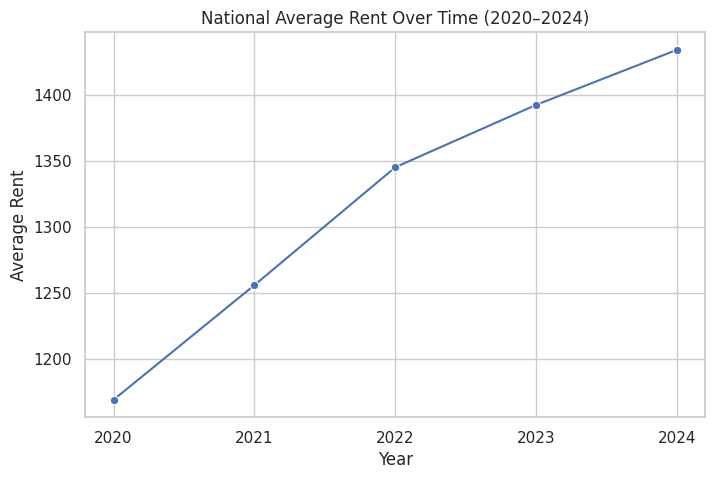

In [7]:
national_level_rent = (
    analysis_df.groupby("year", as_index=False)["state_avg_rent"]
    .mean()
    .sort_values("year")
    )

# Plotting rent level across US from 202-24
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))
sns.lineplot(data=national_level_rent, x="year", y="state_avg_rent", marker="o")
plt.title("National Average Rent Over Time (2020–2024)")
plt.xlabel("Year")
plt.ylabel("Average Rent")
plt.xticks(national_level_rent["year"])
plt.show()

#### This figure establishes that rents rose over time nationally, with the sharpest increase from 2020 to 2022. This suggests that post covid housing market experienced especially rapid rent escalation early in the sample, after which growth continued at a slower pace.


#### As I proceed with the analysis, I'll be using percentage growth instead of raw levels. This makes states more comparable, since states start from very different rent, income, and construction levels.


In [8]:
# Creating a Growth Data Frame which I will use for visualizations

merged_20_24 = analysis_df[analysis_df["year"].isin([2020, 2024])].copy()
merged_20_24

# pivot table to get 2020 and 2024 side-by-side
pivot = merged_20_24.pivot_table(
    index="abbreviation",
    columns="year",
    values=["state_avg_rent", "Median_Household_Income", "Total_units"],
    aggfunc="mean"
)

growth = pd.DataFrame({
    "abbreviation": pivot.index,
    "rent_2020": pivot[("state_avg_rent", 2020)],
    "rent_2024": pivot[("state_avg_rent", 2024)],
    "income_2020" : pivot[("Median_Household_Income"), 2020],
    "income_2024" : pivot[("Median_Household_Income"), 2024],
    "units_2020": pivot[("Total_units", 2020)],
    "units_2024": pivot[("Total_units", 2024)],
}).dropna()

# Calculating Growth Rate

growth["rent_growth_pct"] = ((growth["rent_2024"] - growth["rent_2020"]) / growth["rent_2020"]) * 100
growth["income_growth_pct"] = ((growth["income_2024"] - growth["income_2020"]) / growth["income_2020"]) * 100
growth["units_growth_pct"] = ((growth["units_2024"] - growth["units_2020"]) / growth["units_2020"]) * 100


In [9]:
# 1) Average rent vs Year

fig1 = px.choropleth(
    growth,
    locations="abbreviation",
    locationmode="USA-states",
    scope="usa",
    color="rent_growth_pct",
    color_continuous_scale="Reds",
    hover_name="abbreviation",
    hover_data={"rent_growth_pct":":.1f", "rent_2020":":.0f", "rent_2024":":.0f"},
    labels={"rent_growth_pct":"Rent growth (%)"},
    title="Rent Growth by State (2020 - 2024)"
)
fig1.show()
print()



### RENT GROWTH CHOROPLETH
##### Rent growth was not evenly distributed across the country. Some states experienced much larger increases than others, suggesting that national trends alone hide important regional differences. This variation is important because it gives us the cross-state differences needed to compare rent growth with income and housing supply growth. For example, states like Montana, New Hampshire and Conneticut experienced most growth whereas, Minnesota, West Virginia and Idaho experienced least rent growth.



In [10]:
fig2 = px.choropleth(
    growth,
    locations="abbreviation",
    locationmode="USA-states",
    scope="usa",
    color="income_growth_pct",
    color_continuous_scale="Blues",
    hover_name="abbreviation",
    hover_data={"income_growth_pct":":.1f", "income_2020":":.0f", "income_2024":":.0f"},
    labels={"income_growth_pct":"Income growth (%)"},
    title="Income Growth by State (2020 - 2024)"
)
fig2.show()
print()

### INCOME GROWTH CHOROPLETH
##### Income growth appears reletively more moderate and more evenly distributed than rent growth. While some states experienced stronger increases in household income, the variation across states is less dramatic than what is observed in rent growth.If income growth were the main driver of rent increases, we would expect states with the highest income growth to also be the states with the highest rent growth. However, this is not the case. Idaho, for example, had one of the least rent growth but one of the highest income growth rate.

In [11]:
fig3 = px.choropleth(
    growth,
    locations="abbreviation",
    locationmode="USA-states",
    scope="usa",
    color="units_growth_pct",
    color_continuous_scale="Greens",
    hover_name="abbreviation",
    hover_data={"units_growth_pct":":.1f", "units_2020":":.0f", "units_2024":":.0f"},
    labels={"units_growth_pct":"Housing supply growth (%)"},
    title="Housing Supply Growth by State (2020 - 2024)"
)
fig3.show()

### HOUSING SUPPLY GROWTH CHOROPLETH
##### The housing supply growth map shows substantial variation in new housing construction across states during the same period. Some states experienced strong growth in housing supply, while others showed relatively limited growth or even declines. Because housing supply reflects the availability of new housing units entering the market, this variable captures the supply-side dynamics of the housing market. If housing scarcity is an important driver of rent increases, we would expect states with weaker housing supply growth to exhibit stronger rent growth. Comparing this map with the rent growth map suggests that supply constraints may play a role in explaining why rents rose faster in certain states.

##### Looking at all three maps together, rent appears to vary more dramatically across states than income growth. While income did rise in many places, the differences in income growth across states are not as large as the differences observed in rent increases. On the other hand, housing supply growth shows noticeable variation across states too. This suggests that some states (like New Mexico and Kentucky) expanded their housing stock more than others. This pattern hints that housing supply constaints may play an important role in explaining rent increases.

##### However, visual checks may not be enough to reach at such a conclusion. Therefore, in the next sections, we will make comparisons using scatterplots and linear regression

Now that we have a general idea of how the three variables have changed over time, it might be useful to look at the following comparisons:

1) Rent growth vs Income Growth
2) Rent Growth vs Housing Supply Growth.

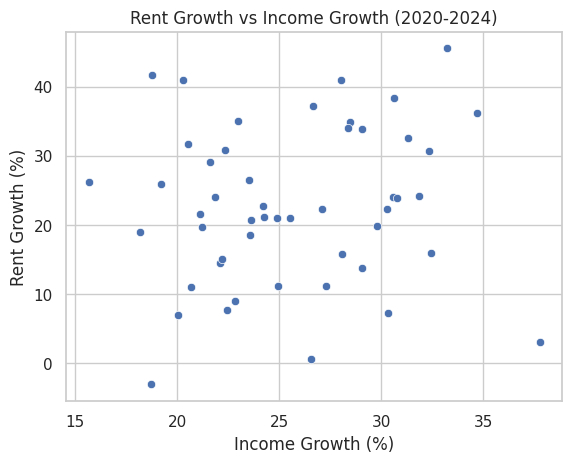

In [12]:
# Rent vs Income

plt.figure()
sns.scatterplot(
    data=growth,
    x="income_growth_pct",
    y="rent_growth_pct"
)
plt.title("Rent Growth vs Income Growth (2020-2024)")
plt.xlabel("Income Growth (%)")
plt.ylabel("Rent Growth (%)")
plt.show()

print()

##### This scatterplot, which shows rent growth with income growth, shows a slight upward tendency but the overall pattern is fairly disperesed. Many states with similar growth in income experienced vastly different rent increases. This indicates that only growth in income does not influence rent gowth. There are likely to be other factors as well which might be influencing changes in rent as well.

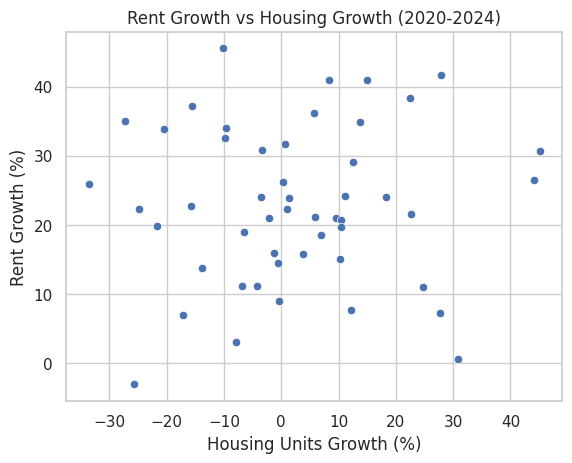

In [13]:
# Rent vs Housing

plt.figure()
sns.scatterplot(
    data=growth,
    x="units_growth_pct",
    y="rent_growth_pct"
)
plt.title("Rent Growth vs Housing Growth (2020-2024)")
plt.xlabel("Housing Units Growth (%)")
plt.ylabel("Rent Growth (%)")
plt.show()

##### The second scatterplot compares rent growth with housing supply. Rather than a clear negative relationship where rent growth increases with decreasing housing supply, we see widely scattered pattern. Some states with strong housing growth experienced large rent increases wheras those with weak housing growth saw only moderate increases in rent. Again, housing supply growth do influence rent dynamics to an extent but cannot be used to fully explain rent charges on its own.

##### Together, both the scatterplots indicate that neither income growth not housing supply growth can alone explain the variation in rent growth across states. The relationships are weak since they appear to be dispersed visually. To further evaluate these relationships and quantify which of these two factors is associated more strongly with rent growth, we would need to use a linear regression model.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

import math

In [15]:
# Preparing regression dataset

reg_df = growth[["rent_growth_pct", "income_growth_pct", "units_growth_pct"]].dropna().copy()

X = reg_df[["income_growth_pct", "units_growth_pct"]]
y = reg_df["rent_growth_pct"]

# Scaling X and fitting regression

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

lr = LinearRegression()
lr.fit(X_scaled, y)

# Predictions on full data
y_pred = lr.predict(X_scaled)

# Calculating RMSE
mse = mean_squared_error(y, y_pred)
rmse = math.sqrt(mse)

print("EXPLANATORY LINEAR REGRESSION RESULTS")
print("RMSE:", round(rmse, 3))
#print("R^2:", round(r2, 3))
print("Intercept:", round(lr.intercept_, 3))
print("Coefficients:")

for feature, coef in zip(X.columns, lr.coef_):
    print(f"{feature}: {round(coef, 3)}")



EXPLANATORY LINEAR REGRESSION RESULTS
RMSE: 11.152
Intercept: 19.132
Coefficients:
income_growth_pct: 5.772
units_growth_pct: 2.236


##### The linear regression model was used to examine whether rent growth across U.S. states from 2020 to 2024 is more closely associated with income growth or housing supply growth. The model produced an RMSE of 11.152, meaning the predicted rent growth values are on average about 11 percentage points away from the actual values. This suggests that while the model captures some general patterns, income growth and housing supply growth alone do not fully explain the variation in rent growth across states.

##### Looking at the coefficients, income growth has a value of 5.772 while housing supply growth has a value of 2.236. Both variables are positively associated with rent growth in the model, but the larger coefficient for income growth suggests that rent increases are somewhat more associated with income growth than with housing supply growth.

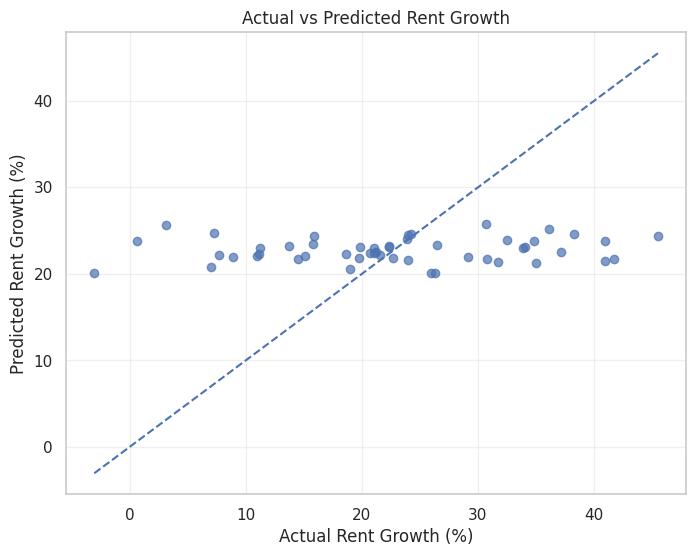


Sample of prediction errors:


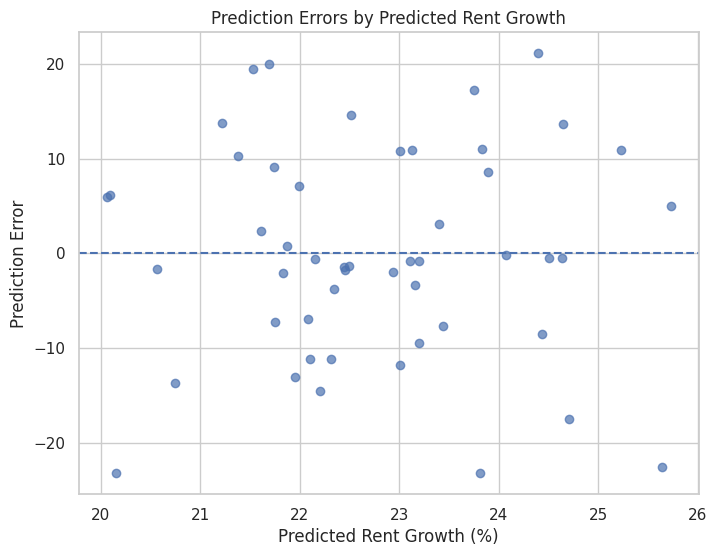

In [16]:
# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.7)
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    linestyle="--"
)
plt.xlabel("Actual Rent Growth (%)")
plt.ylabel("Predicted Rent Growth (%)")
plt.title("Actual vs Predicted Rent Growth")
plt.grid(alpha=0.3)
plt.show()

# Prediction Errors
# Positive prediction error means actual rent growth was higher than predicted
# Vice versa for negative prediction error
prediction_errors = y - y_pred

error_df = pd.DataFrame({
    "Actual Rent Growth": y.values,
    "Predicted Rent Growth": y_pred,
    "Prediction Error": prediction_errors
})

print("\nSample of prediction errors:")

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, prediction_errors, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Rent Growth (%)")
plt.ylabel("Prediction Error")
plt.title("Prediction Errors by Predicted Rent Growth")
plt.show()

##### The actual versus predicted plot shows that most predictions fall within a narrow range around 20–25 percent, while actual rent growth varies much more widely. This indicates that the model tends to predict values close to the average and struggles to capture states with particularly high or low rent growth. The prediction error plot further shows that the model both overpredicts and underpredicts rent growth across states, reinforcing the idea that these variables alone cannot fully explain rent growth differences.

##### **CONCLUSION:** Overall, the regression results suggest that income growth appears to have a stronger association with rent growth than housing supply growth, but neither variable alone fully explains the variation in rent growth across states.

### REFLECTION

This project sharpened up my data analytical skills which include data cleaning, visualization and statistical analysis. I think one of my biggest strengths was the way I cleaned my datasets, chose relevant columns for analysis and merged the data frames into one single data frame, making it all ready to be analysed. I also think I did good with the visualizations part. I used a good mix consisting of line graphs, choropleths and scatterplots to show national level and state level trends.

The analysis part involving linear regression was also decent and confirmed that income growth and housing supply growth do not fully explain differences in rent growth. However, if I had more time, I would have run a cross validation test as well to evaluate how consistently the regression model performs across different subsets of the data rather than relying on one overall fit.

In the future, I would improve by implementing cross validation as it would make my conclusion even stronger.